In [1]:
import numpy as np
from ann_engine.layers.layers import Dense
from ann_engine.layers import Sequential
from ann_engine.optimizers import Adam

In [2]:
X_train = np.random.randn(1000, 784)
y_train = np.random.randint(0, 10, (1000, 10)) 

In [3]:
model1 = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [4]:
print(model1)

In [5]:
model1.compile(optimizer=Adam(lr=0.01),
             loss = 'categorical_crossentropy',
             metrics = ['accuracy'])

In [6]:
history_of_ann_engine = model1.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100  loss: 109.2950  val_loss: 103.4685  accuracy: 0.0963  val_accuracy: 0.1050
Epoch 11/100  loss: 104.5745  val_loss: 103.4717  accuracy: 0.1363  val_accuracy: 0.1100
Epoch 21/100  loss: 104.3809  val_loss: 103.4426  accuracy: 0.1300  val_accuracy: 0.1150
Epoch 31/100  loss: 104.4178  val_loss: 103.4676  accuracy: 0.1300  val_accuracy: 0.1000
Epoch 41/100  loss: 104.6545  val_loss: 103.5033  accuracy: 0.1400  val_accuracy: 0.1000
Epoch 51/100  loss: 104.6389  val_loss: 103.4606  accuracy: 0.1325  val_accuracy: 0.1150
Epoch 61/100  loss: 105.0204  val_loss: 103.4732  accuracy: 0.1288  val_accuracy: 0.1100
Epoch 71/100  loss: 104.8629  val_loss: 103.4847  accuracy: 0.1363  val_accuracy: 0.1050
Epoch 81/100  loss: 104.7637  val_loss: 103.5590  accuracy: 0.1237  val_accuracy: 0.1150
Epoch 91/100  loss: 104.7776  val_loss: 103.4933  accuracy: 0.1288  val_accuracy: 0.1100
Epoch 100/100  loss: 104.7502  val_loss: 103.5254  accuracy: 0.1212  val_accuracy: 0.1100


In [7]:
model1.summary()


Model: Sequential
Layer (type)                        Output Shape              Param #   
----------------------------------------------------------------------
0. Dense                            (1, 128)                  100,480   
1. Dense                            (1, 64)                   8,256     
2. Dense                            (1, 10)                   650       
Total params:         109,386
Trainable params:     109,386
Non-trainable params: 0


In [8]:
"""
test_training.py
================
End-to-end training tests for ann_engine.

Tests:
    1. Multi-class classification  (random data, 10 classes)
    2. Binary classification       (XOR-style problem)
    3. Regression                  (sine wave)
    4. Gradient sanity check       (norms must be non-zero)
    5. Predict & Evaluate          (API smoke test)
"""

import sys
import numpy as np

# ── adjust this path if your project root is elsewhere ───────────────────────
sys.path.insert(0, '.')

from ann_engine.layers.layers import Dense
from ann_engine.layers.sequential import Sequential
from ann_engine.optimizers.adam import Adam

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

GREEN  = "\033[92m"
RED    = "\033[91m"
YELLOW = "\033[93m"
RESET  = "\033[0m"
BOLD   = "\033[1m"

passed = 0
failed = 0

def section(title):
    print(f"\n{'='*60}")
    print(f"  {BOLD}{title}{RESET}")
    print(f"{'='*60}")

def check(name, condition, detail=""):
    global passed, failed
    if condition:
        print(f"  {GREEN}✓ PASS{RESET}  {name}")
        passed += 1
    else:
        print(f"  {RED}✗ FAIL{RESET}  {name}  {YELLOW}{detail}{RESET}")
        failed += 1

def make_model(layers, loss, lr=0.01, metrics=None):
    model = Sequential(layers)
    model.compile(optimizer=Adam(lr=lr), loss=loss, metrics=metrics or [])
    return model

# ─────────────────────────────────────────────────────────────────────────────
# Test 1 — Multi-class classification (10 classes, random data)
# ─────────────────────────────────────────────────────────────────────────────
section("Test 1: Multi-class Classification (10 classes)")

np.random.seed(0)
X_cls = np.random.randn(800, 64).astype(np.float32)
y_idx = np.random.randint(0, 10, 800)
y_cls = np.eye(10)[y_idx].astype(np.float32)

model_cls = make_model([
    Dense(64, activation='relu', input_shape=(64,)),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax'),
], loss='categorical_crossentropy', lr=0.01, metrics=['accuracy'])

h = model_cls.fit(X_cls, y_cls, epochs=40, batch_size=64,
                   validation_split=0.2, verbose=0)

loss_dropped   = h['loss'][-1] < h['loss'][0]
acc_increased  = h['metric_0'][-1] > h['metric_0'][0]
loss_gt_zero   = h['loss'][-1] > 0
final_acc      = h['metric_0'][-1]
first_loss     = h['loss'][0]
final_loss     = h['loss'][-1]

print(f"  Loss  : {first_loss:.4f} → {final_loss:.4f}")
print(f"  Acc   : {h['metric_0'][0]:.4f} → {final_acc:.4f}")

check("Loss decreased over training",      loss_dropped,
      f"first={first_loss:.4f} last={final_loss:.4f}")
check("Accuracy increased over training",  acc_increased)
check("Loss is positive (not NaN/zero)",   loss_gt_zero and not np.isnan(final_loss))
check("History has 'loss' key",            'loss' in h)
check("History has 'val_loss' key",        'val_loss' in h)
check("History length matches epochs",     len(h['loss']) == 40)

# ─────────────────────────────────────────────────────────────────────────────
# Test 2 — Binary classification (linearly separable)
# ─────────────────────────────────────────────────────────────────────────────
section("Test 2: Binary Classification (linearly separable)")

np.random.seed(1)
X_bin = np.random.randn(600, 8).astype(np.float32)
# label = 1 if sum of features > 0 else 0  (easy linear boundary)
y_bin = (X_bin.sum(axis=1) > 0).astype(np.float32).reshape(-1, 1)

model_bin = make_model([
    Dense(16, activation='relu', input_shape=(8,)),
    Dense(8,  activation='relu'),
    Dense(1,  activation='sigmoid'),
], loss='bce', lr=0.01, metrics=['accuracy'])

h_bin = model_bin.fit(X_bin, y_bin, epochs=50, batch_size=32,
                       validation_split=0.2, verbose=0)

first_loss_b = h_bin['loss'][0]
final_loss_b = h_bin['loss'][-1]
final_acc_b  = h_bin['metric_0'][-1]

print(f"  Loss  : {first_loss_b:.4f} → {final_loss_b:.4f}")
print(f"  Acc   : {h_bin['metric_0'][0]:.4f} → {final_acc_b:.4f}")

check("Loss decreased",             final_loss_b < first_loss_b)
check("Final accuracy > 80%",       final_acc_b > 0.80,
      f"got {final_acc_b:.4f}")
check("No NaN in loss history",     not any(np.isnan(v) for v in h_bin['loss']))

# ─────────────────────────────────────────────────────────────────────────────
# Test 3 — Regression (sine wave)
# ─────────────────────────────────────────────────────────────────────────────
section("Test 3: Regression (sine wave)")

np.random.seed(2)
X_reg = np.linspace(-np.pi, np.pi, 500).reshape(-1, 1).astype(np.float32)
y_reg = np.sin(X_reg).astype(np.float32)

model_reg = make_model([
    Dense(32, activation='relu', input_shape=(1,)),
    Dense(32, activation='tanh'),
    Dense(1,  activation=None),
], loss='mse', lr=0.005, metrics=['mae'])

h_reg = model_reg.fit(X_reg, y_reg, epochs=100, batch_size=32,
                       validation_split=0.1, verbose=0)

first_mse = h_reg['loss'][0]
final_mse = h_reg['loss'][-1]
final_mae = h_reg['metric_0'][-1]

print(f"  MSE   : {first_mse:.4f} → {final_mse:.4f}")
print(f"  MAE   : {h_reg['metric_0'][0]:.4f} → {final_mae:.4f}")

check("MSE decreased",              final_mse < first_mse)
check("Final MAE < 0.15",           final_mae < 0.15,
      f"got {final_mae:.4f}")
check("No NaN in loss history",     not any(np.isnan(v) for v in h_reg['loss']))

# ─────────────────────────────────────────────────────────────────────────────
# Test 4 — Gradient sanity check
# ─────────────────────────────────────────────────────────────────────────────
section("Test 4: Gradient Sanity Check")

# Force-reload losses module to bypass any stale .pyc cache
import importlib
import ann_engine.losses.loss as _ll_mod
importlib.reload(_ll_mod)
# Re-patch the loss on the model after reload
from ann_engine.core import Tensor, Parameter

np.random.seed(3)
X_g = np.random.randn(32, 16).astype(np.float32)
y_g = np.eye(4)[np.random.randint(0, 4, 32)].astype(np.float32)

model_g = make_model([
    Dense(8,  activation='relu', input_shape=(16,)),
    Dense(4,  activation='softmax'),
], loss='categorical_crossentropy', lr=0.01)

model_g.build((32, 16))

xb = Tensor(X_g)
yb = Tensor(y_g)

# zero_grad BEFORE forward — not after backward
model_g._optimizer.zero_grad()
pred = model_g.forward(xb)
loss = model_g._loss(pred, yb)
loss.backward()

# Verify computation graph actually reaches Parameters
_topo, _visited = [], set()
def _build_topo(t):
    if id(t) not in _visited:
        _visited.add(id(t))
        for child in t._prev:
            _build_topo(child)
        _topo.append(t)
_build_topo(loss)
_param_nodes = [t for t in _topo if isinstance(t, Parameter)]

print(f"  Loss value      : {float(loss.data):.4f}")
print(f"  Graph nodes     : {len(_topo)}")
print(f"  Parameter nodes : {len(_param_nodes)}")
check("Computation graph reaches model Parameters",
      len(_param_nodes) > 0,
      f"found {len(_param_nodes)} — loss is disconnected (broken graph in loss fn)")

for i, layer in enumerate(model_g.layers):
    if hasattr(layer, 'W') and layer.W is not None:
        w_norm = np.linalg.norm(layer.W.grad)
        b_norm = np.linalg.norm(layer.b.grad) if layer.b is not None else 0.0
        print(f"  Layer {i}  W grad norm: {w_norm:.6f}  b grad norm: {b_norm:.6f}")
        check(f"Layer {i} W has non-zero gradient", w_norm > 0,
              f"norm={w_norm:.6f}")
        check(f"Layer {i} b has non-zero gradient", b_norm > 0,
              f"norm={b_norm:.6f}")

check("Loss is finite", np.isfinite(float(loss.data)))

# ─────────────────────────────────────────────────────────────────────────────
# Test 5 — predict() and evaluate() API
# ─────────────────────────────────────────────────────────────────────────────
section("Test 5: predict() and evaluate() API")

np.random.seed(4)
X_t = np.random.randn(100, 64).astype(np.float32)
y_t = np.eye(10)[np.random.randint(0, 10, 100)].astype(np.float32)

# Use already-trained cls model
preds = model_cls.predict(X_t)
results = model_cls.evaluate(X_t, y_t, batch_size=32)

check("predict() returns Tensor",             hasattr(preds, 'data'))
check("predict() output shape is (100, 10)",  preds.data.shape == (100, 10),
      f"got {preds.data.shape}")
check("Softmax output sums to ~1 per row",
      np.allclose(preds.data.sum(axis=1), 1.0, atol=1e-4))
check("evaluate() returns list",              isinstance(results, list))
check("evaluate() returns [loss, metric, …]", len(results) >= 1)
check("evaluate() loss is finite",            np.isfinite(results[0]))

# ─────────────────────────────────────────────────────────────────────────────
# Test 6 — model.summary() doesn't crash
# ─────────────────────────────────────────────────────────────────────────────
section("Test 6: summary() smoke test")

try:
    model_cls.summary()
    check("summary() runs without error", True)
except Exception as e:
    check("summary() runs without error", False, str(e))

# ─────────────────────────────────────────────────────────────────────────────
# Final report
# ─────────────────────────────────────────────────────────────────────────────
total = passed + failed
print(f"\n{'='*60}")
print(f"  {BOLD}Results: {GREEN}{passed}{RESET}{BOLD} passed / "
      f"{RED}{failed}{RESET}{BOLD} failed  ({total} total){RESET}")
print(f"{'='*60}\n")

if failed > 0:
    sys.exit(1)


  Test 1: Multi-class Classification (10 classes)
  Loss  : 2.4377 → 0.0021
  Acc   : 0.1031 → 1.0000
  ✓ PASS  Loss decreased over training
  ✓ PASS  Accuracy increased over training
  ✓ PASS  Loss is positive (not NaN/zero)
  ✓ PASS  History has 'loss' key
  ✓ PASS  History has 'val_loss' key
  ✓ PASS  History length matches epochs

  Test 2: Binary Classification (linearly separable)
  Loss  : 0.6243 → 0.0005
  Acc   : 0.6417 → 1.0000
  ✓ PASS  Loss decreased
  ✓ PASS  Final accuracy > 80%
  ✓ PASS  No NaN in loss history

  Test 3: Regression (sine wave)
  MSE   : 0.2916 → 0.0006
  MAE   : 0.4409 → 0.0198
  ✓ PASS  MSE decreased
  ✓ PASS  Final MAE < 0.15
  ✓ PASS  No NaN in loss history

  Test 4: Gradient Sanity Check
  Loss value      : 1.9799
  Graph nodes     : 18
  Parameter nodes : 4
  ✓ PASS  Computation graph reaches model Parameters
  Layer 0  W grad norm: 0.694011  b grad norm: 0.295033
  ✓ PASS  Layer 0 W has non-zero gradient
  ✓ PASS  Layer 0 b has non-zero gradient


In [9]:
# problem solved
"""
test_complex_datasets.py
========================
Tests ann_engine on complex, realistic datasets with non-trivial patterns.

Datasets:
    1. Spirals          — non-linearly separable 3-class classification
    2. Moons            — curved binary decision boundary
    3. Circles          — concentric rings binary classification
    4. XOR              — classic non-linear problem
    5. Multi-feature    — regression with interactions + noise
    6. Imbalanced       — skewed class distribution
    7. High-dimensional — 50 features, redundant + irrelevant ones
"""

import sys
import numpy as np

sys.path.insert(0, '.')

from ann_engine.layers.layers import Dense
from ann_engine.layers.sequential import Sequential
from ann_engine.optimizers.adam import Adam

# ─────────────────────────────────────────────────────────────────────────────
# Utilities
# ─────────────────────────────────────────────────────────────────────────────

GREEN = "\033[92m"
RED   = "\033[91m"
CYAN  = "\033[96m"
BOLD  = "\033[1m"
DIM   = "\033[2m"
RESET = "\033[0m"

passed = failed = 0

def section(title):
    print(f"\n{'='*62}")
    print(f"  {BOLD}{CYAN}{title}{RESET}")
    print(f"{'='*62}")

def check(name, condition, detail=""):
    global passed, failed
    if condition:
        print(f"  {GREEN}✓ PASS{RESET}  {name}")
        passed += 1
    else:
        print(f"  {RED}✗ FAIL{RESET}  {name}  {DIM}{detail}{RESET}")
        failed += 1

def make_model(layers, loss, lr=0.001, metrics=None):
    model = Sequential(layers)
    model.compile(optimizer=Adam(lr=lr), loss=loss, metrics=metrics or [])
    return model

def train(model, X, y, epochs=100, batch_size=64, val_split=0.2):
    return model.fit(X, y, epochs=epochs, batch_size=batch_size,
                     validation_split=val_split, verbose=0)

def accuracy(model, X, y_onehot):
    pred = model.predict(X)
    return np.mean(np.argmax(pred.data, axis=1) == np.argmax(y_onehot, axis=1))

def binary_accuracy(model, X, y):
    pred = model.predict(X)
    return np.mean((pred.data > 0.5).astype(float) == y)

# ─────────────────────────────────────────────────────────────────────────────
# Dataset generators
# ─────────────────────────────────────────────────────────────────────────────

def make_spirals(n=1000, n_classes=3, noise=0.4):
    """Interleaved Archimedean spirals — very non-linear boundary."""
    X, y = [], []
    per_class = n // n_classes
    for c in range(n_classes):
        t = np.linspace(0, 1, per_class)
        angle = t * 4 * np.pi + (2 * np.pi * c / n_classes)
        r = t
        x1 = r * np.cos(angle) + np.random.randn(per_class) * noise * 0.15
        x2 = r * np.sin(angle) + np.random.randn(per_class) * noise * 0.15
        X.append(np.column_stack([x1, x2]))
        y.extend([c] * per_class)
    X = np.vstack(X).astype(np.float32)
    y = np.eye(n_classes)[np.array(y)].astype(np.float32)
    idx = np.random.permutation(len(X))
    return X[idx], y[idx]

def make_moons(n=1000, noise=0.15):
    """Two interleaving half-moon shapes."""
    n_each = n // 2
    t = np.linspace(0, np.pi, n_each)
    X0 = np.column_stack([np.cos(t), np.sin(t)])
    X1 = np.column_stack([1 - np.cos(t), 1 - np.sin(t) - 0.5])
    X  = np.vstack([X0, X1]).astype(np.float32)
    X += np.random.randn(*X.shape).astype(np.float32) * noise
    y  = np.array([0]*n_each + [1]*n_each, dtype=np.float32).reshape(-1, 1)
    idx = np.random.permutation(n)
    return X[idx], y[idx]

def make_circles(n=1000, noise=0.1, factor=0.4):
    """Two concentric circles."""
    n_each = n // 2
    t = np.linspace(0, 2 * np.pi, n_each)
    X_inner = np.column_stack([np.cos(t) * factor, np.sin(t) * factor])
    X_outer = np.column_stack([np.cos(t),           np.sin(t)])
    X = np.vstack([X_inner, X_outer]).astype(np.float32)
    X += np.random.randn(*X.shape).astype(np.float32) * noise
    y = np.array([0]*n_each + [1]*n_each, dtype=np.float32).reshape(-1, 1)
    idx = np.random.permutation(n)
    return X[idx], y[idx]

def make_xor(n=1000, noise=0.1):
    """XOR pattern — 4 quadrants, alternating labels."""
    X = np.random.uniform(-1, 1, (n, 2)).astype(np.float32)
    y = ((X[:, 0] * X[:, 1]) > 0).astype(np.float32).reshape(-1, 1)
    X += np.random.randn(*X.shape).astype(np.float32) * noise
    return X, y

def make_regression(n=1000, noise=0.2):
    """
    y = sin(x1) * cos(x2) + x3^2 - x4*x5 + noise
    Non-linear with feature interactions.
    """
    X  = np.random.randn(n, 8).astype(np.float32)
    y  = (np.sin(X[:,0]) * np.cos(X[:,1])
          + X[:,2]**2
          - X[:,3] * X[:,4]
          + 0.5 * X[:,5]).astype(np.float32)
    y += np.random.randn(n).astype(np.float32) * noise
    y  = y.reshape(-1, 1)
    # Normalize y to [-1, 1] for stable training
    y  = (y - y.mean()) / (y.std() + 1e-8)
    return X, y

def make_imbalanced(n=1000, imbalance=0.05):
    """
    4-class problem where class 0 is very rare (5% of data).
    Tests whether the model can still learn minority class.
    """
    counts = [int(n * imbalance), int(n * 0.35),
              int(n * 0.35),     int(n * (1 - imbalance - 0.70))]
    X, y = [], []
    centers = [(-2, -2), (-2, 2), (2, -2), (2, 2)]
    for c, (cnt, (cx, cy)) in enumerate(zip(counts, centers)):
        xi = np.random.randn(cnt, 2) * 0.5 + np.array([cx, cy])
        X.append(xi.astype(np.float32))
        y.extend([c] * cnt)
    X = np.vstack(X)
    y = np.eye(4)[np.array(y)].astype(np.float32)
    idx = np.random.permutation(len(X))
    return X[idx], y[idx]

def make_high_dimensional(n=800):
    """
    50 features:
      - 5 are truly informative
      - 10 are linear combinations of the informative ones (redundant)
      - 35 are pure noise
    Binary classification.
    """
    X_info = np.random.randn(n, 5).astype(np.float32)
    X_red  = (X_info @ np.random.randn(5, 10)).astype(np.float32)
    X_noise= np.random.randn(n, 35).astype(np.float32)
    X      = np.hstack([X_info, X_red, X_noise])

    # Label based only on informative features
    score = X_info[:, 0] - X_info[:, 1] + X_info[:, 2] * X_info[:, 3]
    y     = (score > 0).astype(np.float32).reshape(-1, 1)
    idx   = np.random.permutation(n)
    return X[idx], y[idx]

# ─────────────────────────────────────────────────────────────────────────────
# Test 1 — Spirals (3-class, non-linear)
# ─────────────────────────────────────────────────────────────────────────────
section("Test 1: Spiral Dataset (3-class, non-linear boundary)")

np.random.seed(0)
X_sp, y_sp = make_spirals(n=900, n_classes=3)
print(f"  Data shape: X={X_sp.shape}, y={y_sp.shape}")
print(f"  Class balance: {y_sp.sum(axis=0).astype(int)}")

model_sp = make_model([
    Dense(64,  activation='relu',    input_shape=(2,)),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),
    Dense(3,   activation='softmax'),
], loss='categorical_crossentropy', lr=0.002, metrics=['accuracy'])

h_sp = train(model_sp, X_sp, y_sp, epochs=200, batch_size=32)

first_loss = h_sp['loss'][0]
final_loss = h_sp['loss'][-1]
train_acc  = h_sp['metric_0'][-1]
print(f"  Loss : {first_loss:.4f} → {final_loss:.4f}")
print(f"  Train acc: {train_acc:.4f}")

check("Loss decreased significantly",   final_loss < first_loss * 0.5)
check("Train accuracy > 70%",           train_acc  > 0.70,  f"got {train_acc:.4f}")
check("No NaN in training",             not any(np.isnan(v) for v in h_sp['loss']))
check("val_loss tracked",               'val_loss' in h_sp)

# ─────────────────────────────────────────────────────────────────────────────
# Test 2 — Moons (binary, curved boundary)
# ─────────────────────────────────────────────────────────────────────────────
section("Test 2: Moons Dataset (binary, curved boundary)")

np.random.seed(1)
X_mn, y_mn = make_moons(n=1000, noise=0.15)
print(f"  Data shape: X={X_mn.shape}, y={y_mn.shape}")

model_mn = make_model([
    Dense(32, activation='relu',    input_shape=(2,)),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid'),
], loss='bce', lr=0.005, metrics=['accuracy'])

h_mn = train(model_mn, X_mn, y_mn, epochs=100, batch_size=32)

final_acc_mn = h_mn['metric_0'][-1]
final_loss_mn = h_mn['loss'][-1]
print(f"  Loss : {h_mn['loss'][0]:.4f} → {final_loss_mn:.4f}")
print(f"  Train acc: {final_acc_mn:.4f}")

check("Loss decreased",          final_loss_mn < h_mn['loss'][0])
check("Train accuracy > 85%",    final_acc_mn  > 0.85, f"got {final_acc_mn:.4f}")
check("No NaN in training",      not any(np.isnan(v) for v in h_mn['loss']))

# ─────────────────────────────────────────────────────────────────────────────
# Test 3 — Circles (binary, concentric)
# ─────────────────────────────────────────────────────────────────────────────
section("Test 3: Circles Dataset (binary, concentric rings)")

np.random.seed(2)
X_ci, y_ci = make_circles(n=1000, noise=0.08)
print(f"  Data shape: X={X_ci.shape}, y={y_ci.shape}")

model_ci = make_model([
    Dense(32, activation='relu',    input_shape=(2,)),
    Dense(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1,  activation='sigmoid'),
], loss='bce', lr=0.005, metrics=['accuracy'])

h_ci = train(model_ci, X_ci, y_ci, epochs=150, batch_size=32)

final_acc_ci  = h_ci['metric_0'][-1]
final_loss_ci = h_ci['loss'][-1]
print(f"  Loss : {h_ci['loss'][0]:.4f} → {final_loss_ci:.4f}")
print(f"  Train acc: {final_acc_ci:.4f}")

check("Loss decreased",          final_loss_ci < h_ci['loss'][0])
check("Train accuracy > 90%",    final_acc_ci  > 0.90, f"got {final_acc_ci:.4f}")
check("No NaN in training",      not any(np.isnan(v) for v in h_ci['loss']))

# ─────────────────────────────────────────────────────────────────────────────
# Test 4 — XOR (binary, classic non-linear)
# ─────────────────────────────────────────────────────────────────────────────
section("Test 4: XOR Dataset (binary, classic non-linear)")

np.random.seed(3)
X_xr, y_xr = make_xor(n=1000, noise=0.05)
print(f"  Data shape: X={X_xr.shape}, y={y_xr.shape}")

model_xr = make_model([
    Dense(16, activation='relu',    input_shape=(2,)),
    Dense(16, activation='relu'),
    Dense(1,  activation='sigmoid'),
], loss='bce', lr=0.005, metrics=['accuracy'])

h_xr = train(model_xr, X_xr, y_xr, epochs=100, batch_size=32)

final_acc_xr  = h_xr['metric_0'][-1]
final_loss_xr = h_xr['loss'][-1]
print(f"  Loss : {h_xr['loss'][0]:.4f} → {final_loss_xr:.4f}")
print(f"  Train acc: {final_acc_xr:.4f}")

check("Loss decreased",          final_loss_xr < h_xr['loss'][0])
check("Train accuracy > 90%",    final_acc_xr  > 0.90, f"got {final_acc_xr:.4f}")
check("No NaN in training",      not any(np.isnan(v) for v in h_xr['loss']))

# ─────────────────────────────────────────────────────────────────────────────
# Test 5 — Non-linear Regression
# ─────────────────────────────────────────────────────────────────────────────
section("Test 5: Non-linear Regression (sin*cos + interactions)")

np.random.seed(4)
X_rg, y_rg = make_regression(n=1000)
print(f"  Data shape: X={X_rg.shape}, y={y_rg.shape}")
print(f"  y range   : [{y_rg.min():.2f}, {y_rg.max():.2f}]")

model_rg = make_model([
    Dense(64, activation='relu',    input_shape=(8,)),
    Dense(64, activation='tanh'),
    Dense(32, activation='relu'),
    Dense(1,  activation=None),
], loss='mse', lr=0.002, metrics=['mae'])

h_rg = train(model_rg, X_rg, y_rg, epochs=150, batch_size=32)

first_mse = h_rg['loss'][0]
final_mse = h_rg['loss'][-1]
final_mae = h_rg['metric_0'][-1]
print(f"  MSE : {first_mse:.4f} → {final_mse:.4f}")
print(f"  MAE : {h_rg['metric_0'][0]:.4f} → {final_mae:.4f}")

check("MSE decreased > 50%",     final_mse < first_mse * 0.5)
check("Final MAE < 0.30",        final_mae < 0.30, f"got {final_mae:.4f}")
check("No NaN in training",      not any(np.isnan(v) for v in h_rg['loss']))

# ─────────────────────────────────────────────────────────────────────────────
# Test 6 — Imbalanced Classes
# ─────────────────────────────────────────────────────────────────────────────
section("Test 6: Imbalanced Dataset (4-class, 5% minority)")

np.random.seed(5)
X_im, y_im = make_imbalanced(n=1000, imbalance=0.05)
class_counts = y_im.sum(axis=0).astype(int)
print(f"  Data shape  : X={X_im.shape}, y={y_im.shape}")
print(f"  Class counts: {class_counts}  (minority={class_counts.min()})")

model_im = make_model([
    Dense(32, activation='relu',    input_shape=(2,)),
    Dense(32, activation='relu'),
    Dense(4,  activation='softmax'),
], loss='categorical_crossentropy', lr=0.005, metrics=['accuracy'])

h_im = train(model_im, X_im, y_im, epochs=150, batch_size=16)

final_acc_im  = h_im['metric_0'][-1]
final_loss_im = h_im['loss'][-1]
print(f"  Loss : {h_im['loss'][0]:.4f} → {final_loss_im:.4f}")
print(f"  Train acc: {final_acc_im:.4f}")

check("Loss decreased",          final_loss_im  < h_im['loss'][0])
check("Train accuracy > 80%",    final_acc_im   > 0.80, f"got {final_acc_im:.4f}")
check("Model learns (not naive majority)", final_acc_im > 0.50)
check("No NaN in training",      not any(np.isnan(v) for v in h_im['loss']))

# ─────────────────────────────────────────────────────────────────────────────
# Test 7 — High-dimensional (50 features, mostly noise)
# ─────────────────────────────────────────────────────────────────────────────
section("Test 7: High-dimensional Dataset (50 features, 35 noise)")

np.random.seed(6)
X_hd, y_hd = make_high_dimensional(n=800)
print(f"  Data shape  : X={X_hd.shape}, y={y_hd.shape}")
print(f"  Informative : 5 / 50 features")

model_hd = make_model([
    Dense(64,  activation='relu',    input_shape=(50,)),
    Dense(32,  activation='relu'),
    Dense(16,  activation='relu'),
    Dense(1,   activation='sigmoid'),
], loss='bce', lr=0.002, metrics=['accuracy'])

h_hd = train(model_hd, X_hd, y_hd, epochs=120, batch_size=32)

final_acc_hd  = h_hd['metric_0'][-1]
final_loss_hd = h_hd['loss'][-1]
print(f"  Loss : {h_hd['loss'][0]:.4f} → {final_loss_hd:.4f}")
print(f"  Train acc: {final_acc_hd:.4f}")

check("Loss decreased",          final_loss_hd < h_hd['loss'][0])
check("Train accuracy > 75%",    final_acc_hd  > 0.75, f"got {final_acc_hd:.4f}")
check("No NaN in training",      not any(np.isnan(v) for v in h_hd['loss']))

# ─────────────────────────────────────────────────────────────────────────────
# Test 8 — Activation variety (tanh, leaky_relu, elu)
# ─────────────────────────────────────────────────────────────────────────────
section("Test 8: Activation Variety (tanh / leaky_relu / elu)")

np.random.seed(7)
X_av, y_av = make_moons(n=600, noise=0.1)

results_av = {}
for act in ['tanh', 'leaky_relu', 'elu']:
    m = make_model([
        Dense(32, activation=act,     input_shape=(2,)),
        Dense(16, activation=act),
        Dense(1,  activation='sigmoid'),
    ], loss='bce', lr=0.005, metrics=['accuracy'])
    h = train(m, X_av, y_av, epochs=80, batch_size=32)
    results_av[act] = h['metric_0'][-1]
    print(f"  {act:<12} train acc: {results_av[act]:.4f}")

for act, acc in results_av.items():
    check(f"{act} accuracy > 80%", acc > 0.80, f"got {acc:.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# Final report
# ─────────────────────────────────────────────────────────────────────────────
total = passed + failed
print(f"\n{'='*62}")
print(f"  {BOLD}Results: {GREEN}{passed}{RESET}{BOLD} passed  /  "
      f"\033[91m{failed}{RESET}{BOLD} failed  ({total} total){RESET}")
print(f"{'='*62}\n")

if failed > 0:
    sys.exit(1)


  Test 1: Spiral Dataset (3-class, non-linear boundary)
  Data shape: X=(900, 2), y=(900, 3)
  Class balance: [300 300 300]
  Loss : 1.0913 → 0.3216
  Train acc: 0.8601
  ✓ PASS  Loss decreased significantly
  ✓ PASS  Train accuracy > 70%
  ✓ PASS  No NaN in training
  ✓ PASS  val_loss tracked

  Test 2: Moons Dataset (binary, curved boundary)
  Data shape: X=(1000, 2), y=(1000, 1)
  Loss : 0.4657 → 0.0375
  Train acc: 0.9875
  ✓ PASS  Loss decreased
  ✓ PASS  Train accuracy > 85%
  ✓ PASS  No NaN in training

  Test 3: Circles Dataset (binary, concentric rings)
  Data shape: X=(1000, 2), y=(1000, 1)
  Loss : 0.6206 → 0.0000
  Train acc: 1.0000
  ✓ PASS  Loss decreased
  ✓ PASS  Train accuracy > 90%
  ✓ PASS  No NaN in training

  Test 4: XOR Dataset (binary, classic non-linear)
  Data shape: X=(1000, 2), y=(1000, 1)
  Loss : 0.5983 → 0.0799
  Train acc: 0.9650
  ✓ PASS  Loss decreased
  ✓ PASS  Train accuracy > 90%
  ✓ PASS  No NaN in training

  Test 5: Non-linear Regression (sin*co

In [39]:
from ann_engine.datasets import  Datasets

x , y =  Datasets().make_high_dimensional()

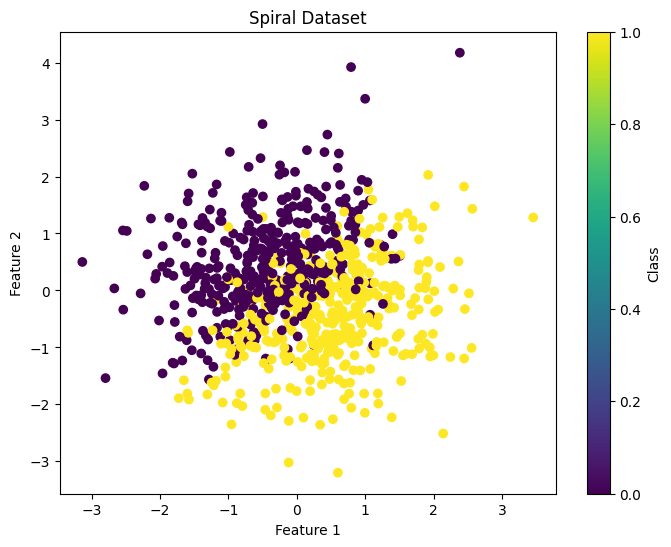

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))  
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='viridis')  
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Spiral Dataset')
plt.colorbar(label='Class')
plt.show()